In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 68.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

Found 1920 validation images
Plotting first 5: ['img000008.jpg', 'img000012.jpg', 'img000016.jpg', 'img000027.jpg', 'img000042.jpg']


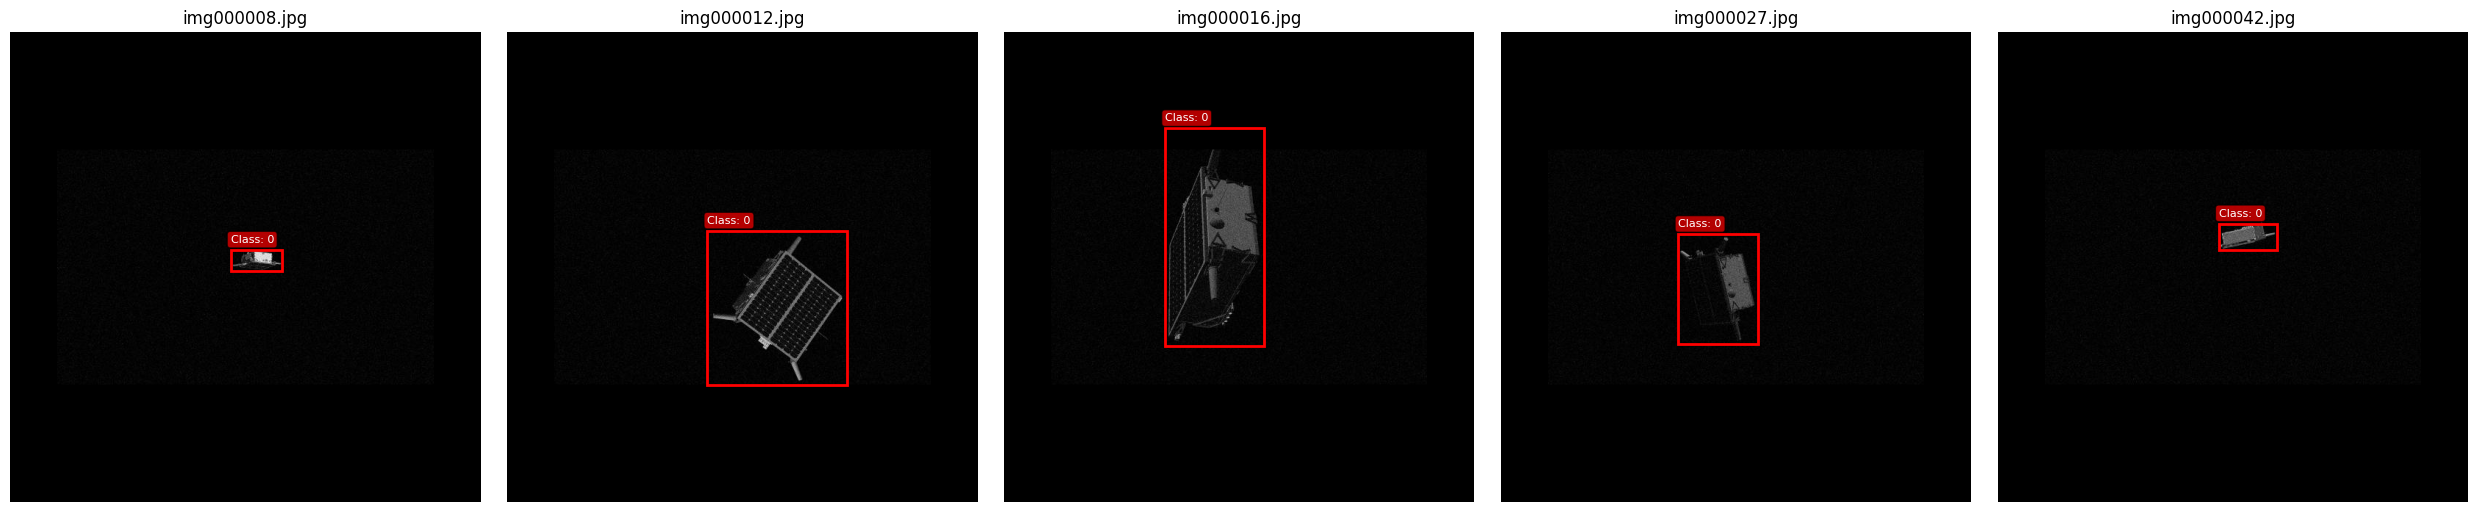


Dataset Statistics:
Validation images: 1920
Validation labels: 1920


In [2]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Paths to your YOLO dataset
val_images_dir = '/kaggle/input/speeddatasetforyolo/yolo_dataset/images/val'
val_labels_dir = '/kaggle/input/speeddatasetforyolo/yolo_dataset/labels/val'

# Get first 5 validation images
val_images = sorted(os.listdir(val_images_dir))[:5]
print(f"Found {len(os.listdir(val_images_dir))} validation images")
print(f"Plotting first 5: {val_images}")

# Create subplot for 5 images
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, img_file in enumerate(val_images):
    # Image and label paths
    img_path = os.path.join(val_images_dir, img_file)
    label_file = os.path.splitext(img_file)[0] + '.txt'
    label_path = os.path.join(val_labels_dir, label_file)
    
    # Load and display image
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f'{img_file}')
    axes[i].axis('off')
    
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            line = f.readline().strip()
            if line:
                parts = line.split()
                class_id = int(parts[0])
                x_center, y_center, width, height = map(float, parts[1:5])
                
                img_width, img_height = img.size
                
                x_min = (x_center - width/2) * img_width
                y_min = (y_center - height/2) * img_height
                box_width = width * img_width
                box_height = height * img_height
                
                rect = patches.Rectangle(
                    (x_min, y_min), box_width, box_height,
                    linewidth=2, edgecolor='red', facecolor='none'
                )
                axes[i].add_patch(rect)
                
                axes[i].text(x_min, y_min-10, f'Class: {class_id}', 
                           bbox=dict(boxstyle="round,pad=0.3", facecolor="red", alpha=0.7),
                           fontsize=8, color='white')
    else:
        axes[i].text(0.5, 0.5, 'No label file', transform=axes[i].transAxes, 
                    ha='center', va='center', fontsize=12, color='red')

plt.tight_layout()
plt.show()

# Print dataset statistics
print(f"\nDataset Statistics:")
print(f"Validation images: {len(os.listdir(val_images_dir))}")
print(f"Validation labels: {len(os.listdir(val_labels_dir))}")


In [3]:
import yaml
import ultralytics
import os
from pathlib import Path
Path('/kaggle/working').mkdir(parents=True, exist_ok=True)

dataset_config = {
    'path': '/kaggle/input/speeddatasetforyolo/yolo_dataset',
    'train': 'images/train',
    'val': 'images/val',
    'names': {0: 'tango_satellite'},
    'nc': 1
}

yaml_path = '/kaggle/working/custom_dataset.yaml'

with open(yaml_path, 'w') as f:
    yaml.dump(dataset_config, f, default_flow_style=False)

print(f"YAML file created successfully at: {yaml_path}")

with open(yaml_path, 'r') as f:
    print("\nFile contents:")
    print(f.read())


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YAML file created successfully at: /kaggle/working/custom_dataset.yaml

File contents:
names:
  0: tango_satellite
nc: 1
path: /kaggle/input/speeddatasetforyolo/yolo_dataset
train: images/train
val: images/val



In [4]:
from ultralytics import YOLO
model = YOLO("/kaggle/input/yolo12n/yolo12n.pt")
results = model.train(data="/kaggle/working/custom_dataset.yaml", epochs=120, imgsz=640, batch=32, device=[0, 1])

Ultralytics 8.3.167 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
                                                        CUDA:1 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/custom_dataset.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/input/yolo12n/yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, op

100%|██████████| 755k/755k [00:00<00:00, 17.5MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  2    180864  ultralytics.nn.modules.block.A2C2f           [128, 128, 2, True, 4]        
  7                  -1  1    295424  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 75.1MB/s]


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.7±1.0 ms, read: 6.2±2.3 MB/s, size: 20.2 KB)


...

                   all       1920       1920      0.999      0.999      0.995      0.963

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


    120/120      4.72G     0.4283     0.2377     0.8553         16        640: 100%|██████████| 240/240 [01:16<00:00,  3.14it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 60/60 [00:14<00:00,  4.16it/s]


                   all       1920       1920      0.999      0.999      0.995      0.963

120 epochs completed in 3.120 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train/weights/best.pt, 5.5MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.167 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
                                                        CUDA:1 (Tesla T4, 15095MiB)
YOLOv12n summary (fused): 159 layers, 2,556,923 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 60/60 [00:15<00:00,  3.90it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all       1920       1920      0.999      0.999      0.995      0.963
Speed: 0.2ms preprocess, 3.9ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs/detect/train
